In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
master_df = pd.read_csv('Team_Stats_Merge_2018_2025.csv')

In [25]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Columns: 121 entries, season to made_playoffs
dtypes: float64(68), int64(52), str(1)
memory usage: 242.1 KB


In [26]:
corr_matrix = master_df.corr(numeric_only=True)

In [27]:


upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column].abs() > 0.85)
]

print(high_corr)

['tp_L', 'tp_W-L%', 'tp_PD', 'tp_MoV', 'tp_SRS', 'tp_OSRS', 'tp_DSRS', 'off_pts', 'off_yds', 'off_yds_per_play', 'off_penalty_yds', 'off_score_pct', 'off_turnover_pct', 'off_exp', 'def_g', 'def_pa', 'def_yds_per_play', 'def_score_pct', 'def_turnover_pct', 'def_exp', 'off_pass_G', 'off_pass_Att', 'off_pass_TD%', 'off_pass_Int', 'off_pass_Int%', 'off_pass_Y/A', 'off_pass_AY/A', 'off_pass_Y/G', 'off_pass_Rate', 'off_pass_Yds.1', 'off_pass_Sk%', 'off_pass_NY/A', 'off_pass_ANY/A', 'off_pass_EXP', 'off_rush_G', 'off_rush_Yds', 'off_rush_Y/G', 'def_pass_G', 'def_pass_Att', 'def_pass_TD%', 'def_pass_Int', 'def_pass_Int%', 'def_pass_Y/A', 'def_pass_AY/A', 'def_pass_Y/G', 'def_pass_Rate', 'def_pass_Yds.1', 'def_pass_Sk%', 'def_pass_NY/A', 'def_pass_ANY/A', 'def_pass_EXP', 'def_rush_G', 'def_rush_Y/G', 'def_adv_G', 'def_adv_Att', 'def_adv_Cmp', 'def_adv_Yds', 'def_adv_TD', 'def_adv_Sk']


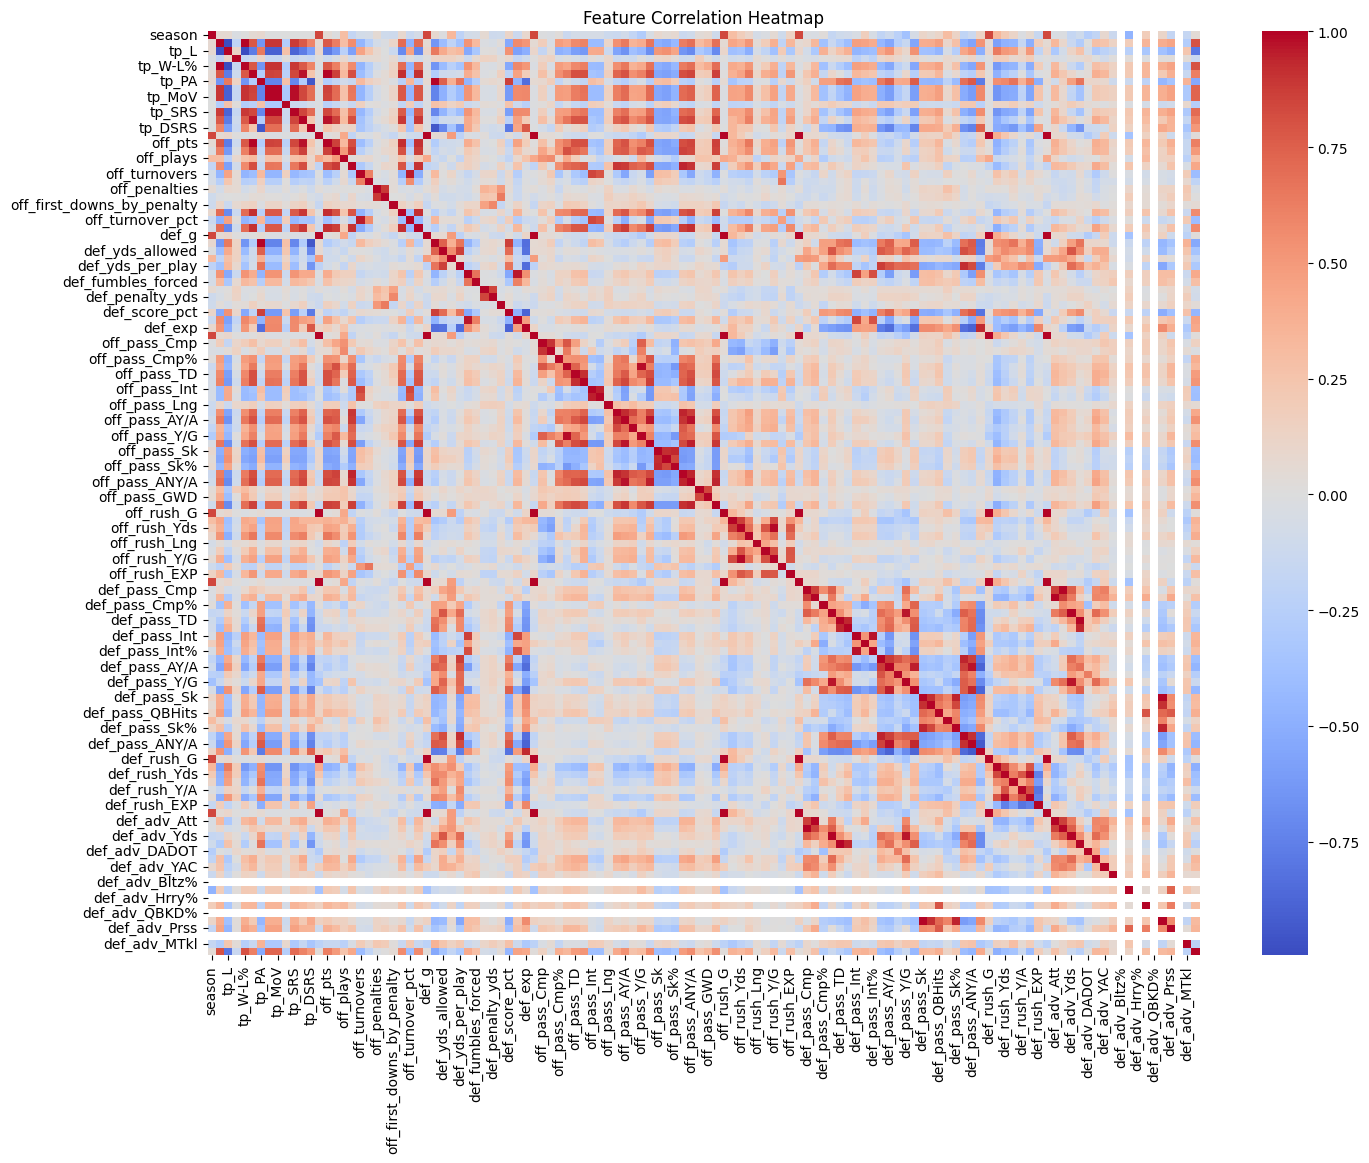

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))
sns.heatmap(master_df.corr(numeric_only=True),
            cmap="coolwarm",
            center=0)

plt.title("Feature Correlation Heatmap")
plt.show()

## Test All Feautres

In [29]:
# Drop non-feature columns
drop_cols = ["season", "team", "made_playoffs"]  # adjust if needed

X = master_df.drop(columns=drop_cols)
y = master_df["made_playoffs"]

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Simple split (this is fine for feature importance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(25)

,feature,importance
3,tp_W-L%,0.129266
1,tp_L,0.097271
0,tp_W,0.085432
6,tp_PD,0.041192
9,tp_SRS,0.040593
7,tp_MoV,0.039309
13,off_pts,0.029950
4,tp_PF,0.028531
60,off_pass_EXP,0.026538
22,off_score_pct,0.022587


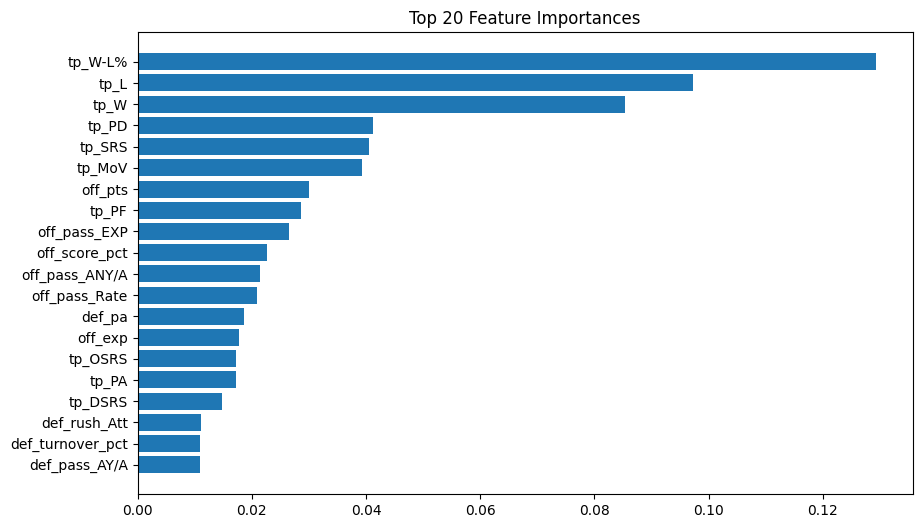

In [32]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

## Define trival features

Features that are obvious and should not be remove because of noise.

Redundant features/ highly correlated features

`off_pass_Yds.1` = yards lost due to sacks

In [148]:
trivial_features = ['tp_W-L%',
                    'tp_L',
                    'tp_W',
                    'tp_PD',
                    'tp_SRS',
                    'tp_OSRS',
                    'tp_DSRS',
                    'off_pts',
                    'def_pa',
                    'tp_MoV',
                    'def_pass_AY/A',
                    'off_pass_AY/A',
                    'off_pass_NY/A',
                    'def_pass_NY/A',
                    'def_pass_Y/A',
                    'off_pass_Y/A',
                    'tp_PF',
                    'tp_PA',
                    'off_pass_EXP',
                    'def_pass_EXP',
                    'def_exp',
                    'off_exp',
                    'off_rush_exp',
                    'off_rush_EXP',
                    'off_yds',
                    'def_yds_allowed',
                    'off_turnovers',
                    'def_turnovers_forced',
                    'off_pass_Yds',
                    'def_rush_Yds',
                    'off_rush_Yds',
                    'def_pass_Yds',
                    'off_pass_TD',
                    'off_pass_Y/G',
                    'def_rush_Y/G',
                    'off_pass_Cmp%',
                    'def_rush_Att',
                    'off_rush_Att',
                    'off_rush_Y/G',
                    'def_pass_PD',
                    'off_pass_Int',
                    'off_pass_Int%',
                    'def_pass_Int',
                    'def_pass_Int%',
                    'off_pass_Yds.1',
                    'off_pass_Sk',
                    'off_pass_Sk%',
                    'def_pass_Sk%',
                    'def_pass_Sk',
                    'off_pass_GWD',
                    'def_plays',
                    'off_plays',
                    'def_pass_Att',
                    'off_fumbles',
                    'def_rush_TD',
                    'off_rush_TD',
                    'off_pass_Y/C',
                    'def_pass_Cmp%',
                    'off_rush_Lng',
                    'off_pass_Att',
                    'def_adv_Att',
                    'def_rush_EXP',
                    'def_pass_TD',
                    'def_pass_Y/C',
                    'off_pass_Y/G',
                    'off_rush_fumbles',
                    'def_pass_Y/G',
                    'off_pass_Cmp',
                    'tp_SoS',
                    'def_pass_TFL',
                    'off_pass_Lng',
                    'def_adv_Yds',
                    'def_pass_TD%',
                    'def_adv_Sk',
                    'def_adv_Cmp',
                    'def_penalties',
                    'def_penalty_yds',
                    'off_penalty_yds',
                    'def_pass_Cmp',
                    'off_penalties',
                    'def_adv_TD',
                    'off_pass_4QC',
                    'def_first_downs_by_penalty',
                    'off_first_downs_by_penalty',
                    'tp_T',
                    'off_pass_G',
                    'def_pass_G',
                    'off_g',
                    'def_g',
                    'off_rush_Fmb',
                    'def_fumbles_forced',
                    'off_rush_G',
                    'def_rush_G',
                    'def_adv_G'
                    ]

In [149]:
X = X.drop(columns=trivial_features, errors='ignore')

In [150]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Simple split (this is fine for feature importance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [151]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(30)

,feature,importance
1,off_score_pct,0.129476
7,off_pass_Rate,0.113014
8,off_pass_ANY/A,0.084439
4,def_score_pct,0.067140
13,def_pass_ANY/A,0.064312
5,def_turnover_pct,0.060178
10,def_pass_Rate,0.056527
6,off_pass_TD%,0.055729
2,off_turnover_pct,0.047694
16,def_adv_Air,0.034036


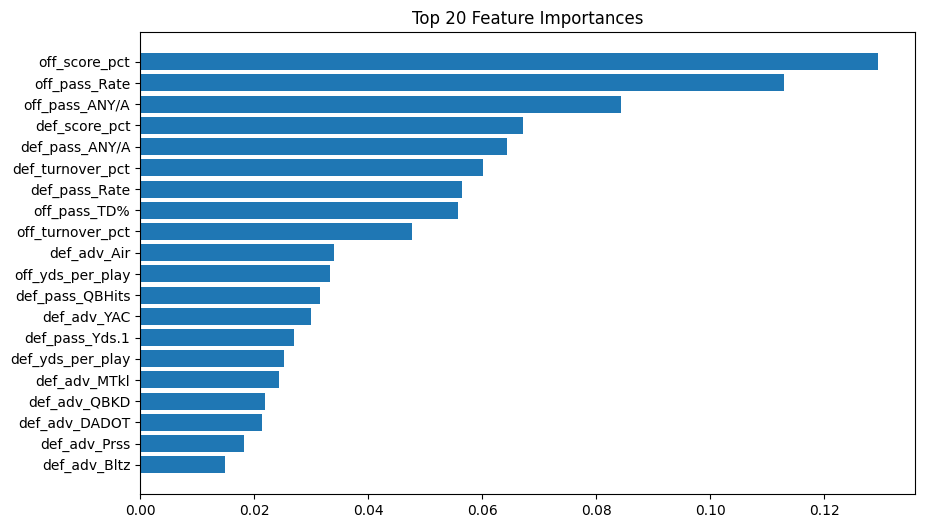

In [152]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

In [10]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# start with predictors only
X = master_df.drop(columns=["made_playoffs"], errors="ignore")

# explicitly drop non-model identifier columns if present
X = X.drop(columns=["team", "season"], errors="ignore")

# keep only numeric columns
X = X.select_dtypes(include=[np.number]).copy()

# replace inf values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# drop rows with missing values for VIF calculation
X = X.dropna()

# force everything to float
X = X.astype(float)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif = vif.sort_values("VIF", ascending=False)
print(vif)

/Users/dylandellavalle/Documents/MDS/Capstone/nfl-decision-support-analytics/.conda/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


            Feature        VIF
0              tp_W        inf
77     def_pass_Int        inf
27  def_yds_allowed        inf
28        def_plays        inf
74     def_pass_Yds        inf
..              ...        ...
99     def_rush_EXP  71.077015
68     off_rush_Fmb  57.783320
65     off_rush_Lng  40.390483
59     off_pass_GWD  37.821115
58     off_pass_4QC  30.211510

[100 rows x 2 columns]


In [13]:
for col in master_df.columns:
    print(col)

season
team
tp_W
tp_L
tp_T
tp_W-L%
tp_PF
tp_PA
tp_PD
tp_MoV
tp_SoS
tp_SRS
tp_OSRS
tp_DSRS
off_g
off_pts
off_yds
off_plays
off_yds_per_play
off_turnovers
off_fumbles
off_penalties
off_penalty_yds
off_first_downs_by_penalty
off_score_pct
off_turnover_pct
off_exp
def_g
def_pa
def_yds_allowed
def_plays
def_yds_per_play
def_turnovers_forced
def_fumbles_forced
def_penalties
def_penalty_yds
def_first_downs_by_penalty
def_score_pct
def_turnover_pct
def_exp
off_pass_G
off_pass_Cmp
off_pass_Att
off_pass_Cmp%
off_pass_Yds
off_pass_TD
off_pass_TD%
off_pass_Int
off_pass_Int%
off_pass_Lng
off_pass_Y/A
off_pass_AY/A
off_pass_Y/C
off_pass_Y/G
off_pass_Rate
off_pass_Sk
off_pass_Yds.1
off_pass_Sk%
off_pass_NY/A
off_pass_ANY/A
off_pass_4QC
off_pass_GWD
off_pass_EXP
off_rush_G
off_rush_Att
off_rush_Yds
off_rush_TD
off_rush_Lng
off_rush_Y/A
off_rush_Y/G
off_rush_Fmb
off_rush_EXP
def_pass_G
def_pass_Cmp
def_pass_Att
def_pass_Cmp%
def_pass_Yds
def_pass_TD
def_pass_TD%
def_pass_Int
def_pass_PD
def_pass_Int%
d

In [24]:

features = [
'tp_SRS','tp_PD',
'off_yds_per_play','off_score_pct','off_turnover_pct','off_exp',
'off_pass_ANY/A','off_pass_TD%','off_pass_Int%',
'off_rush_Y/G','off_rush_EXP',
'def_yds_per_play','def_score_pct','def_turnover_pct','def_exp',
'def_pass_ANY/A','def_pass_Sk%','def_rush_Y/G',
'off_penalty_yds','def_penalty_yds'
]

X = master_df[features]
y = master_df["made_playoffs"]

In [28]:
model_df = pd.concat(
    [
        master_df[["season","team"]],  # identifiers
        X,
        y
    ],
    axis=1
)

model_df

,season,team,tp_SRS,tp_PD,off_yds_per_play,off_score_pct,off_turnover_pct,off_exp,off_pass_ANY/A,off_pass_TD%,...,def_yds_per_play,def_score_pct,def_turnover_pct,def_exp,def_pass_ANY/A,def_pass_Sk%,def_rush_Y/G,off_penalty_yds,def_penalty_yds,made_playoffs
0,2018,New England Patriots,5.2,111,5.9,40.8,9.2,147.66,7.3,5.1,...,5.7,32.6,15.0,-17.25,5.8,4.7,112.7,744,838,1
1,2018,Miami Dolphins,-8.8,-114,5.3,28.3,12.5,-44.43,5.6,5.7,...,6.1,39.9,14.2,-127.44,6.7,5.8,145.3,978,856,0
2,2018,Buffalo Bills,-6.9,-105,4.7,26.4,15.5,-96.90,3.7,2.6,...,4.9,33.3,14.3,16.95,4.9,6.8,114.9,992,976,0
3,2018,New York Jets,-7.8,-108,4.9,32.0,14.7,-97.61,4.8,3.4,...,5.7,39.1,9.9,-70.75,6.5,6.3,126.3,948,817,0
4,2018,Baltimore Ravens,7.0,102,5.3,40.7,10.7,81.02,6.0,3.2,...,4.8,29.1,9.5,30.09,5.2,6.9,82.9,940,1017,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,2025,New Orleans Saints,-4.9,-77,5.0,33.0,13.1,-19.68,5.6,3.2,...,4.8,40.2,11.2,4.59,5.8,8.4,120.6,920,913,0
252,2025,Seattle Seahawks,12.8,191,5.9,45.9,14.2,80.50,7.3,5.2,...,4.6,28.7,12.8,81.09,4.5,7.3,91.9,793,902,1
253,2025,Los Angeles Rams,12.5,172,6.2,47.0,8.3,219.88,8.2,7.7,...,5.2,34.3,14.9,6.16,5.5,7.4,110.8,573,922,1
254,2025,San Francisco 49ers,6.0,66,5.5,47.6,12.9,131.06,6.8,5.7,...,5.6,38.6,8.4,-115.46,7.1,3.3,107.8,651,734,1


In [29]:
model_df.to_csv("team_stats_model_ready.csv", index=False)